# 10 — Comparaison sur un scénario précis : prix fixe vs Q-table vs DQN

Tu choisis **un artiste et une salle** ; les trois agents jouent **le même
scénario** (même graine → même population, même demande, même calendrier de
visites de base). On compare la trajectoire de ventes, la courbe de prix et la
**marge de contribution** de la billetterie :

`marge = (prix − marginal_cost + ancillary_capture · Fan Cost Index) · billets`

soit CA billetterie **+** revenus annexes (merch, bar, parking) **−** coûts
variables par spectateur (billetterie, personnel, paiement). C'est l'objectif
que les agents RL optimisent.

> Prérequis : des modèles entraînés — `notebooks/07` pour la Q-table, `08` pour le
> DQN. Sans eux, seul le prix fixe s'affiche.
> Après une modif de `env/` : **Kernel > Restart** (autoreload ne resynchronise
> pas `STATE_BINS` ni la forme de l'observation).

In [13]:
%load_ext autoreload
%autoreload 2

import os
import sys
import importlib

sys.path.append(os.path.abspath("../env"))
sys.path.append(os.path.abspath("../pricing_agent"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Recharge la chaîne complète DANS L'ORDRE des dépendances (noms en chaîne -> pas
# de collision avec une variable locale) : refdata -> agents -> market -> gym_wrapper
def _reload_project():
    for _name in ("refdata", "agents", "market", "gym_wrapper"):
        importlib.reload(importlib.import_module(_name))

_reload_project()
from gym_wrapper import TicketEnv
from agent_fixed import FixedPriceAgent
from agent_qtable import QTableAgent

# Garde-fou : si l'env n'a pas les champs récents, le reload a échoué -> redémarrer le kernel.
if "ca_total" not in TicketEnv(horizon=10).reset(seed=0)[1]:
    raise RuntimeError("Environnement périmé — fais 'Kernel > Restart Kernel' puis Run All.")


def chf(x, decimals: int = 0) -> str:
    """Formatage numérique suisse : apostrophe comme séparateur de milliers (1'500)."""
    return f"{x:,.{decimals}f}".replace(",", "'")


try:
    plt.style.use("seaborn-v0_8-darkgrid")
except OSError:
    plt.style.use("ggplot")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# ============================ PARAMÈTRES ====================================
ARTIST    = "Powerwolf"          # cf. data/upsert/artists.csv
VENUE     = "Z7 Konzertfabrik"   # cf. data/upsert/venues.csv
SEED      = 1                    # graine du scénario (population, demande, calendrier de visites)
HORIZON   = 120                  # nombre de pas de vente
PRIX_FIXE = 70.0                 # baseline : prix fixe "réaliste" (instinct de remplir la salle)
DEMANDE   = 1.0                  # multiplicateur de demande : 1.0 = nominal, <1 molle, >1 carton
# ===========================================================================
# À DEMANDE = 1.0 la demande dépasse la capacité : au prix fixe la salle est
# soldée en 1-2 pas (billets bradés). Baisse DEMANDE (0.6-0.8) pour voir des
# trajectoires longues — et le cas où un prix fixe bas devient le bon choix.

ENV_CFG  = dict(horizon=HORIZON, domain_randomize=False)   # demande nominale (pas de bruit aléatoire)
SCENARIO = dict(seed=SEED, options={"artist": ARTIST, "venue": VENUE, "demand_scale": DEMANDE})

print("artistes :", ", ".join(pd.read_csv("../data/upsert/artists.csv")["artist_name"]))
print("salles   :", ", ".join(pd.read_csv("../data/upsert/venues.csv")["venue_name"]))

artistes : Annie Taylor, BABYMETAL, Black Sea Dahu, Electric Callboy, Fontaines D.C., Hans Zimmer, Joe Hisaishi, Kamasi Washington, Powerwolf, Ron Carter, Sabaton, Sophie Hunger, Wynton Marsalis
salles   : Komplex 457, Z7 Konzertfabrik, The Hall, Auditorium Stravinski, Victoria Hall, Hallenstadion


ARTISTE   Powerwolf  (Metal)
  indice de popularité (1-10) : 5.2
  auditeurs mensuels          : 1'151'585
  abonnés                     : 1'113'052
  fidélité (abonnés/auditeurs) : 0.97

SALLE     Z7 Konzertfabrik  (Pratteln)
  capacité                    : 1'500 places
  Fan Cost Index             : 40 CHF / spectateur

DEMANDE
  acheteurs potentiels       : 2'734  (1.82× la capacité)
  budget-billet P10/P50/P90  : 92 / 122 / 151 CHF
  tranches d'âge             : 13-17=54, 18-24=839, 25-34=1268, 35-44=492, 45_plus=81


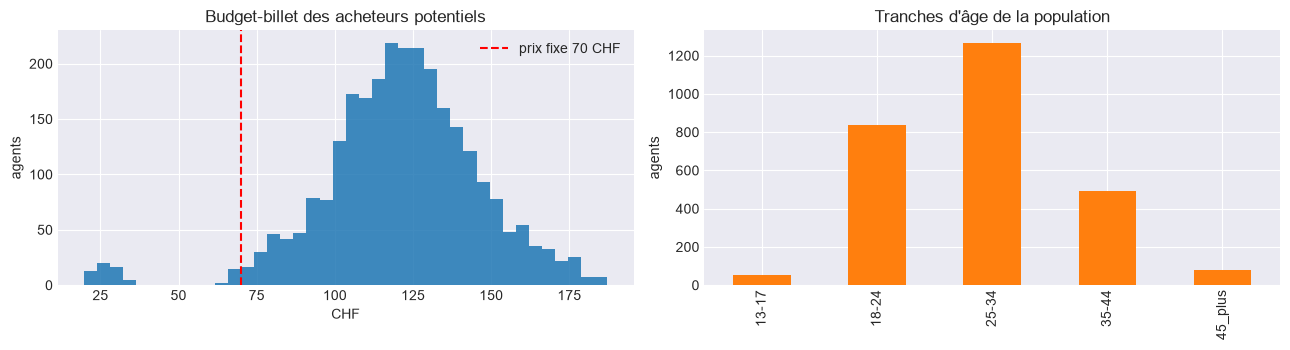

In [15]:
# --- Informations sur le marché (avant l'intervention des agents) ------------
_env = TicketEnv(**ENV_CFG)
_env.reset(**SCENARIO)
m = _env.market
CAP = m.initial_tickets

budgets = np.array([b.budget for b in m.buyers])
ages = pd.Series([b.age_bracket for b in m.buyers]).value_counts().sort_index()

print(f"ARTISTE   {m.artist.name}  ({m.genre.name})")
print(f"  indice de popularité (1-10) : {m.popularity_index:.1f}")
print(f"  auditeurs mensuels          : {chf(m.artist.monthly_listeners)}")
print(f"  abonnés                     : {chf(m.artist.followers)}")
print(f"  fidélité (abonnés/auditeurs) : {m.artist.engagement_ratio:.2f}")
print(f"\nSALLE     {m.venue.name}  ({m.venue.city})")
print(f"  capacité                    : {chf(CAP)} places")
print(f"  Fan Cost Index             : {m.fan_cost_index:.0f} CHF / spectateur")
print(f"\nDEMANDE")
print(f"  acheteurs potentiels       : {chf(m.n_potential_buyers)}  ({m.n_potential_buyers / CAP:.2f}× la capacité)")
print(f"  budget-billet P10/P50/P90  : {np.percentile(budgets, 10):.0f} / {np.percentile(budgets, 50):.0f} / {np.percentile(budgets, 90):.0f} CHF")
print(f"  tranches d'âge             : " + ", ".join(f"{k}={v}" for k, v in ages.items()))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].hist(budgets, bins=40, color="tab:blue", alpha=0.85)
ax[0].axvline(PRIX_FIXE, color="red", ls="--", label=f"prix fixe {PRIX_FIXE:.0f} CHF")
ax[0].set(title="Budget-billet des acheteurs potentiels", xlabel="CHF", ylabel="agents")
ax[0].legend()
ages.plot.bar(ax=ax[1], color="tab:orange")
ax[1].set(title="Tranches d'âge de la population", xlabel="", ylabel="agents")
plt.tight_layout()
plt.show()

In [ ]:
# --- Chargement des agents --------------------------------------------------
fixed = FixedPriceAgent.from_price(PRIX_FIXE)
fixed.name = f"fixe_{PRIX_FIXE:.0f}"
agents = [fixed]

for _delta in (10, 20):                            # prix fixes de référence : PRIX_FIXE + 10, PRIX_FIXE + 20
    _a = FixedPriceAgent.from_price(PRIX_FIXE + _delta)
    _a.name = f"fixe_{PRIX_FIXE + _delta:.0f}"
    agents.append(_a)

try:
    qt = QTableAgent.load()                    # lève ValueError si la grille a changé (ré-entraîner)
    qt.name = "qtable"
    agents.append(qt)
    print(f"Q-table : {qt.path.name}  ({qt.meta.get('episodes', '?')} épisodes, {qt.meta.get('created', '')})")
except (FileNotFoundError, ValueError, OSError, KeyError) as e:
    print("Q-table ignorée :", e)

try:
    from agent_dqn import DQNAgent
    dq = DQNAgent.load()
    _got, _exp = dq.model.input_shape[-1], _env.observation_space.shape[0]
    if _got != _exp:
        raise ValueError(f"modèle à {_got} entrées, l'environnement en attend {_exp} — ré-entraîner (notebook 08)")
    dq.name = "dqn"
    agents.append(dq)
    print(f"DQN     : {dq.path.name}  ({dq.meta.get('episodes', '?')} épisodes, {dq.meta.get('created', '')})")
except (ImportError, FileNotFoundError, ValueError, OSError, KeyError) as e:
    print("DQN ignoré :", e)

print("\nAgents comparés :", [a.name for a in agents])

In [17]:
# --- Un passage complet par agent, sur le même scénario --------------------
def run_scenario(agent):
    env = TicketEnv(**ENV_CFG)
    obs, info = env.reset(**SCENARIO)
    mk = env.market
    rows = []
    done = False
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, reward, term, trunc, info = env.step(action)
        done = term or trunc
        rows.append(dict(
            t=mk.initial_time - mk.time_remaining,
            prix=env._last_price,
            visites=mk.visits_this_step,
            ventes_pas=mk.tickets_sold_this_step,
            ventes_cumul=mk.tickets_sold_total,
            ca_billetterie=info["ticket_revenue_total"],
            ca_total=info["ca_total"],                   # billetterie + revenus annexes
            marge=info["revenue_total"],                 # marge de contribution cumulée (== objectif RL)
            fill=mk.fill_rate,
            actifs_sans_billet=sum(1 for b in mk.buyers if b.visits_made > 0 and not b.has_bought),
        ))
    return pd.DataFrame(rows), info


traj = {a.name: run_scenario(a) for a in agents}


def sold_out_step(df):
    hit = df.index[df["ventes_cumul"] >= CAP]
    return int(df.loc[hit[0], "t"]) if len(hit) else None


summary = pd.DataFrame({
    name: {
        "prix moyen (CHF)": round(df["prix"].mean(), 1),
        "billets vendus": int(df["ventes_cumul"].iloc[-1]),
        "remplissage %": round(100 * df["fill"].iloc[-1], 1),
        "sold-out au pas": sold_out_step(df),
        "CA billetterie (CHF)": round(info["ticket_revenue_total"]),
        "revenus annexes (CHF)": round(info["ancillary_revenue_total"]),
        "CA total (CHF)": round(info["ca_total"]),                 # <- métrique cahier des charges
        "coût variable (CHF)": round(info["variable_cost_total"]),
        "marge contribution (CHF)": round(info["revenue_total"]),  # <- objectif optimisé
    }
    for name, (df, info) in traj.items()
}).T

ref_ca = summary.loc[fixed.name, "CA total (CHF)"]
ref_marge = summary.loc[fixed.name, "marge contribution (CHF)"]
summary["CA vs fixe %"] = (summary["CA total (CHF)"] / ref_ca * 100 - 100).round(1)
summary["marge vs fixe %"] = (summary["marge contribution (CHF)"] / ref_marge * 100 - 100).round(1)
summary

,prix moyen (CHF),billets vendus,remplissage %,sold-out au pas,CA billetterie (CHF),revenus annexes (CHF),CA total (CHF),coût variable (CHF),marge contribution (CHF),CA vs fixe %,marge vs fixe %
fixe_70,70.0,1500.0,100.0,10.0,105000.0,21000.0,126000.0,22500.0,103500.0,0.0,0.0
fixe_80,80.0,1500.0,100.0,13.0,120000.0,21000.0,141000.0,22500.0,118500.0,11.9,14.5
fixe_90,90.0,1500.0,100.0,18.0,135000.0,21000.0,156000.0,22500.0,133500.0,23.8,29.0
qtable,90.0,1500.0,100.0,18.0,135000.0,21000.0,156000.0,22500.0,133500.0,23.8,29.0
dqn,91.7,1478.0,98.5,NaN,146030.0,20692.0,166722.0,22170.0,144552.0,32.3,39.7


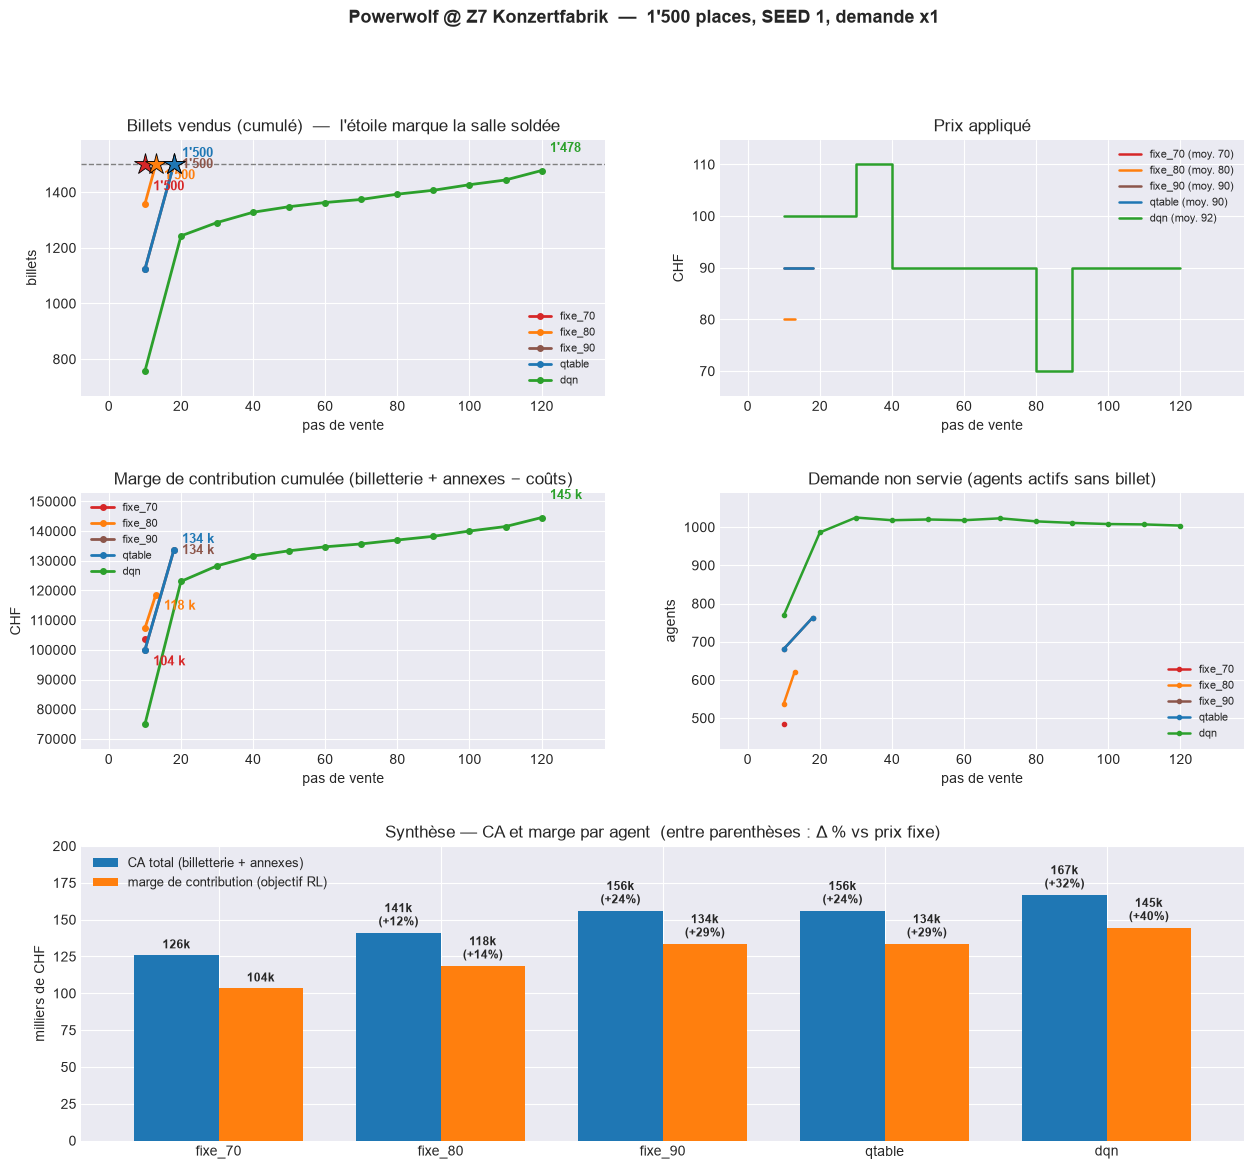

In [18]:
# --- Trajectoires comparées + synthèse chiffrée --------------------------
palette = ["tab:red", "tab:orange", "tab:brown", "tab:blue", "tab:green", "tab:purple"]
colors = {name: palette[i % len(palette)] for i, name in enumerate(traj)}

fig = plt.figure(figsize=(15, 13))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.15], hspace=0.36, wspace=0.22)
ax00, ax01 = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
ax10, ax11 = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])
axbar = fig.add_subplot(gs[2, :])

fig.suptitle(f"{ARTIST} @ {VENUE}  —  {chf(CAP)} places, SEED {SEED}, demande x{DEMANDE:g}",
             fontsize=13, fontweight="bold")

n = len(traj)
for i, (name, (df, _)) in enumerate(traj.items()):
    c = colors[name]
    dy = 8 * (i - (n - 1) / 2)                       # décalage vertical anti-chevauchement
    pm = df["prix"].mean()
    # marqueurs : rendent visibles les trajectoires courtes (sold-out en 1-2 pas)
    ax00.plot(df["t"], df["ventes_cumul"], "o-", ms=4, color=c, lw=2, label=name)
    ax01.step(df["t"], df["prix"], color=c, lw=1.8, where="post", label=f"{name} (moy. {pm:.0f})")
    ax10.plot(df["t"], df["marge"], "o-", ms=4, color=c, lw=2, label=name)
    ax11.plot(df["t"], df["actifs_sans_billet"], "o-", ms=3, color=c, lw=1.8, label=name)

    so = sold_out_step(df)
    if so is not None:                               # marqueur = salle soldée
        y_so = df.loc[df["t"] == so, "ventes_cumul"].iloc[0]
        ax00.plot(so, y_so, "*", ms=16, color=c, mec="black", mew=0.6, zorder=5)

    ax00.annotate(chf(df["ventes_cumul"].iloc[-1]),
                  xy=(df["t"].iloc[-1], df["ventes_cumul"].iloc[-1]), xytext=(6, dy),
                  textcoords="offset points", va="center", fontsize=9, fontweight="bold", color=c)
    ax10.annotate(f"{chf(df['marge'].iloc[-1] / 1000)} k",
                  xy=(df["t"].iloc[-1], df["marge"].iloc[-1]), xytext=(6, dy),
                  textcoords="offset points", va="center", fontsize=9, fontweight="bold", color=c)

ax00.axhline(CAP, color="grey", ls="--", lw=1)
ax00.set(title="Billets vendus (cumulé)  —  l'étoile marque la salle soldée", xlabel="pas de vente", ylabel="billets")
ax01.set(title="Prix appliqué", xlabel="pas de vente", ylabel="CHF")
ax10.set(title="Marge de contribution cumulée (billetterie + annexes − coûts)", xlabel="pas de vente", ylabel="CHF")
ax11.set(title="Demande non servie (agents actifs sans billet)", xlabel="pas de vente", ylabel="agents")
for a in (ax00, ax01, ax10, ax11):
    a.legend(fontsize=8)
    a.margins(x=0.16, y=0.12)                        # marge pour les annotations de bout de courbe

# --- Barres de synthèse : CA total + marge par agent, avec Δ % vs prix fixe ---
names = list(summary.index)
x = np.arange(len(names))
w = 0.38
ca = summary["CA total (CHF)"].to_numpy() / 1000
marge = summary["marge contribution (CHF)"].to_numpy() / 1000

b1 = axbar.bar(x - w / 2, ca, w, label="CA total (billetterie + annexes)", color="tab:blue")
b2 = axbar.bar(x + w / 2, marge, w, label="marge de contribution (objectif RL)", color="tab:orange")
axbar.set_xticks(x, names)
axbar.set_ylabel("milliers de CHF")
axbar.set_title("Synthèse — CA et marge par agent  (entre parenthèses : Δ % vs prix fixe)")
axbar.legend(fontsize=9, loc="upper left")

for bars, pct_col in ((b1, "CA vs fixe %"), (b2, "marge vs fixe %")):
    for rect, name in zip(bars, names):
        h = rect.get_height()
        pct = summary.loc[name, pct_col]
        tag = f"{chf(h)}k" if name == fixed.name else f"{chf(h)}k\n({pct:+.0f}%)"
        axbar.annotate(tag, xy=(rect.get_x() + rect.get_width() / 2, h),
                       xytext=(0, 3), textcoords="offset points",
                       ha="center", va="bottom", fontsize=8.5, fontweight="bold")

axbar.margins(y=0.20)
plt.show()

## Lecture

- **Panneau de synthèse (bas)** : CA total et marge de contribution par agent,
  avec le **Δ % vs prix fixe** entre parenthèses. C'est le chiffre du cahier des
  charges (billetterie + revenus annexes).
- **Marge de contribution** = l'objectif optimisé par les agents
  = `(prix − marginal_cost + ancillary_capture · FCI) · billets`. Vendre *plus*
  de billets ne garantit pas *plus* de marge si le prix est bradé — le
  `marginal_cost` fait un **prix plancher économique**.
- **L'étoile marque la salle soldée** : à `DEMANDE = 1.0` la demande dépasse la
  capacité, donc au prix fixe (et pour une Q-table qui tarife à plat) la salle
  part en 1-2 pas, sous sa valeur. Le DQN étale le prix (haut au lancement,
  ajusté ensuite) et capte la disposition à payer des retardataires → plus de CA
  à remplissage équivalent.
- **Demande non servie** : agents qui ont visité sans acheter — soit prix trop
  haut (demande laissée sur la table), soit salle saturée trop tôt.

### À explorer

Modifie la cellule **Paramètres** puis ré-exécute à partir de là :

- **`DEMANDE`** : à `1.0` les agents RL gagnent largement (ils tarifent au-dessus
  d'un prix fixe qui solde trop bas). Descends à `0.6-0.7` → la salle ne se
  remplit plus, la demande devient le facteur limitant et non le prix : les
  agents, entraînés surtout sur des scénarios à forte demande, calibrent mal et
  **un simple prix fixe repasse devant**. « Battre le prix fixe » dépend du
  régime de demande — à discuter dans le rapport.
- **`ARTIST` / `VENUE`** : niche (`Annie Taylor`, `Komplex 457`) vs superstar
  (`Taylor Swift`, `Hallenstadion`) — le prix optimal passe de ~45 à ~110 CHF.
- **`PRIX_FIXE`** : le prix fixe « réaliste » de référence (défaut 70). Les deux
  autres prix fixes affichés suivent automatiquement — `PRIX_FIXE + 10` et
  `PRIX_FIXE + 20`. L'optimum par scénario tombe souvent dans cette plage, mais
  reste inconnaissable a priori.

> Pour une comparaison **agrégée** sur des centaines de scénarios aléatoires
> (le vrai verdict), voir `notebooks/09` ou `python scripts/run_comparison.py --dqn`.